#### Overview:

The dataset used for this project is the *Dermatology Dataset*, containing **34 attributes — 33 numeric (integer-valued)** and **1 nominal (categorical target)** indicating the type of erythemato-squamous disease.

The diseases include:
- Psoriasis
- Seborrheic Dermatitis
- Lichen Planus
- Pityriasis Rosea
- Chronic Dermatitis
- Pityriasis Rubra Pilaris

The goal was to analyze the data, handle inconsistencies, and develop a robust machine learning model for accurate disease classification.

**Clinical Attributes: (take values 0, 1, 2, 3, unless otherwise indicated):**
- erythema
- scaling
- definite borders
- itching
- koebner phenomenon
- polygonal papules
- follicular papules
- oral mucosal involvement
- knee and elbow involvement
- scalp involvement
- family history, (0 or 1)

**Histopathological Attributes: (take values 0, 1, 2, 3):**
- melanin incontinence
- eosinophils in the infiltrate
- PNL infiltrate
- fibrosis of the papillary dermis
- exocytosis
- acanthosis
- hyperkeratosis
- parakeratosis
- clubbing of the rete ridges
- elongation of the rete ridges



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# loading data set
data = pd.read_csv('dataset_35_dermatology (1).csv')

In [4]:
data

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


# Task 1 :- Complete Data Analysis

In [5]:
data.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [9]:
# Replace common missing marker '?' with NaN
data.replace('?', np.nan, inplace=True)

In [12]:
# Convert numeric-like columns to numeric where appropriate (except class if nominal strings)
for c in data.columns:
    if c != "class":
        data[c] = pd.to_numeric(data[c], errors='coerce')

In [14]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  366 non-null    int64  
 1   scaling                                   366 non-null    int64  
 2   definite_borders                          366 non-null    int64  
 3   itching                                   366 non-null    int64  
 4   koebner_phenomenon                        366 non-null    int64  
 5   polygonal_papules                         366 non-null    int64  
 6   follicular_papules                        366 non-null    int64  
 7   oral_mucosal_involvement                  366 non-null    int64  
 8   knee_and_elbow_involvement                366 non-null    int64  
 9   scalp_involvement                         366 non-null    int64  
 10  family_history                        

In [16]:
print("\nMissing values per column:")
print(data.isnull().sum().sort_values(ascending=False).to_string())


Missing values per column:
Age                                         8
erythema                                    0
vacuolisation_and_damage_of_basal_layer     0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epidermis    0
spongiform_pustule                          0
munro_microabcess                           0
focal_hypergranulosis                       0
disappearance_of_the_granular_layer         0
spongiosis                                  0
parakeratosis                               0
saw-tooth_appearance_of_retes               0
follicular_horn_plug                        0
perifollicular_parakeratosis                0
inflammatory_monoluclear_inflitrate         0
band-like_infiltrate                        0
clubbing_of_the_rete_ridges                 0
hyperkeratosis                              0
scaling                                     0
knee_and_elbow_involvement                  0
definite_borders                            0
itchin

In [17]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if "class" in numeric_cols:
    numeric_cols = [c for c in numeric_cols if c != "class"]

In [20]:
print("\nNumeric feature count:", len(numeric_cols))


Numeric feature count: 34


In [21]:
print("\nDescriptive statistics (numeric features):")
print(data[numeric_cols].describe().transpose().to_string())


Descriptive statistics (numeric features):
                                          count       mean        std  min   25%   50%    75%   max
erythema                                  366.0   2.068306   0.664753  0.0   2.0   2.0   2.00   3.0
scaling                                   366.0   1.795082   0.701527  0.0   1.0   2.0   2.00   3.0
definite_borders                          366.0   1.549180   0.907525  0.0   1.0   2.0   2.00   3.0
itching                                   366.0   1.366120   1.138299  0.0   0.0   1.0   2.00   3.0
koebner_phenomenon                        366.0   0.633880   0.908016  0.0   0.0   0.0   1.00   3.0
polygonal_papules                         366.0   0.448087   0.957327  0.0   0.0   0.0   0.00   3.0
follicular_papules                        366.0   0.166667   0.570588  0.0   0.0   0.0   0.00   3.0
oral_mucosal_involvement                  366.0   0.377049   0.834147  0.0   0.0   0.0   0.00   3.0
knee_and_elbow_involvement                366.0   0.6147

In [25]:
print("\nClass distribution:")
if "class" in data.columns:
    print(data["class"].value_counts().to_string)
else:
    print("No 'class' column found. Please ensure your dataset includes the class column.")


Class distribution:
<bound method Series.to_string of class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64>


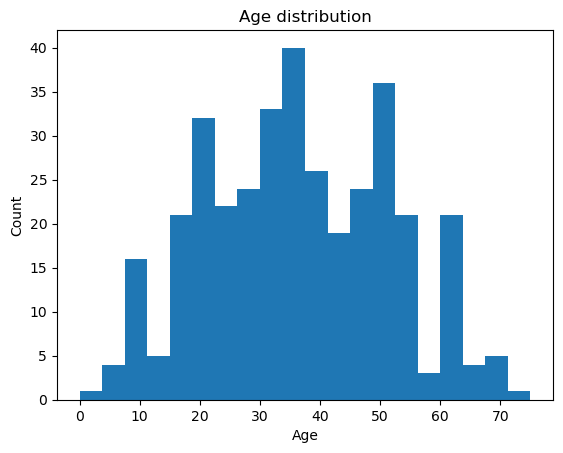

In [31]:
if "Age" in data.columns:
    plt.figure()
    plt.hist(data["Age"].dropna().astype(float), bins=20)
    plt.title("Age distribution")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()

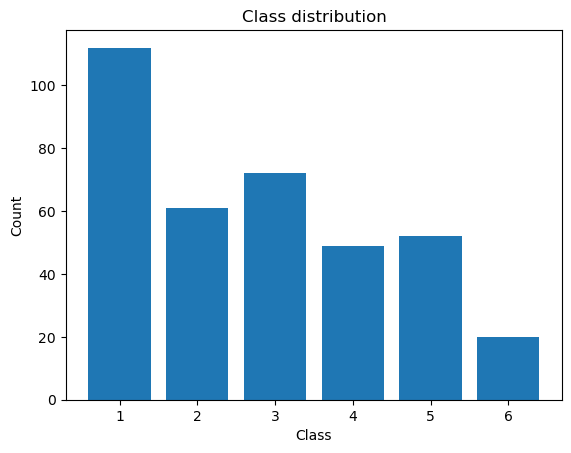

In [32]:
if "class" in data.columns:
    plt.figure()
    vc = data["class"].value_counts().sort_index()
    plt.bar(vc.index.astype(str), vc.values)
    plt.title("Class distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

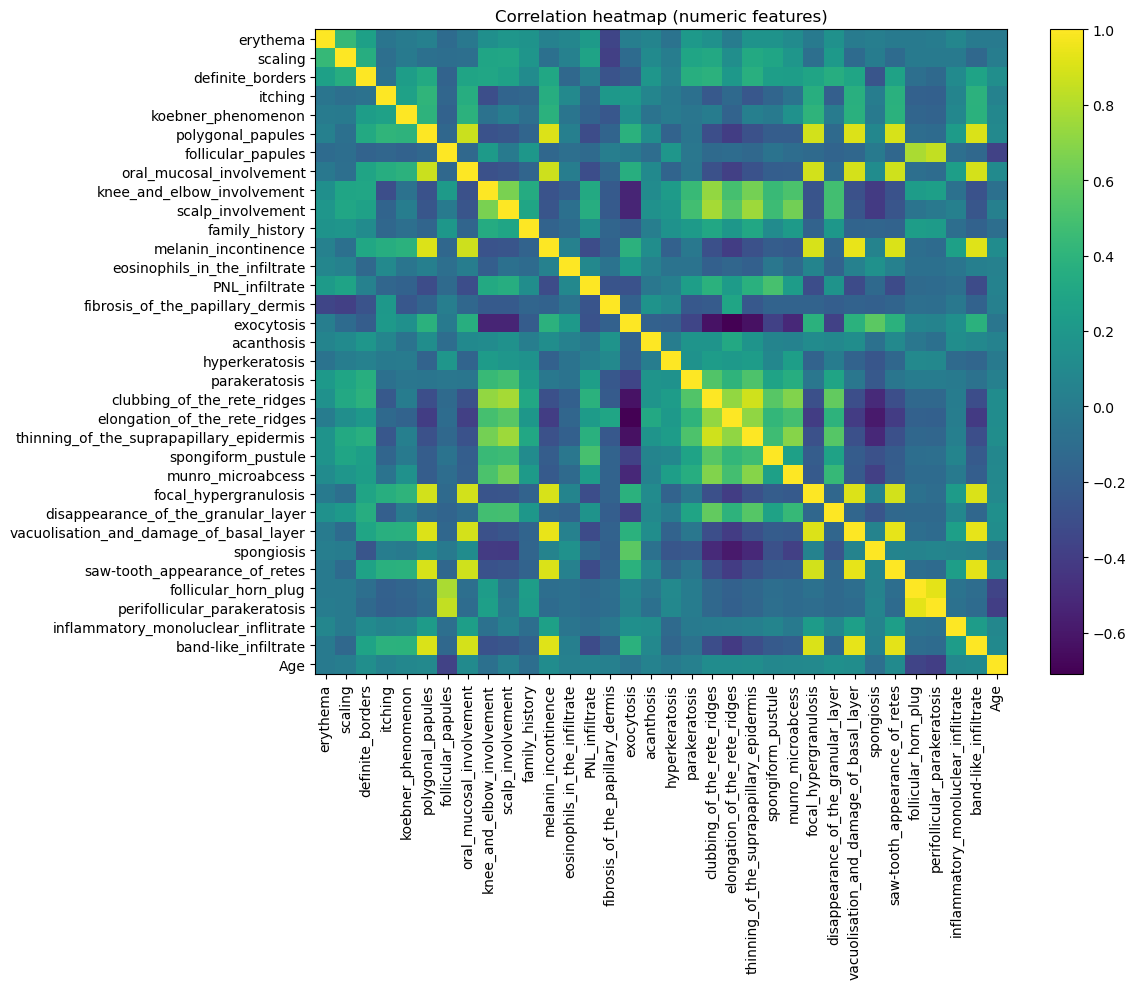

In [33]:
# Correlation heatmap for numeric columns
if len(numeric_cols) > 1:
    corr = data[numeric_cols].corr()
    plt.figure(figsize=(12,10))
    plt.imshow(corr, interpolation='nearest', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
    plt.yticks(range(len(numeric_cols)), numeric_cols)
    plt.title("Correlation heatmap (numeric features)")
    plt.tight_layout()
    plt.show()

# Task 2:- Predictive Model Creation

### Data Preprocessing

In [36]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [37]:
# Preprocessing for modeling
if "class" not in data.columns:
    raise ValueError("Dataset must contain 'class' column for supervised classification.")

In [40]:
# Encode target labels to integers 0..k-1
label_enc = LabelEncoder()
data["class_encoded"] = label_enc.fit_transform(data["class"].astype(str))
print("Class label mapping:")
for orig, enc in zip(label_enc.classes_, range(len(label_enc.classes_))):
    print(f"  {enc} -> {orig}")

Class label mapping:
  0 -> 1
  1 -> 2
  2 -> 3
  3 -> 4
  4 -> 5
  5 -> 6


In [41]:
# Prepare X, y
X = data.drop(columns=["class","class_encoded"])
y = data["class_encoded"].astype(int)

In [42]:
# Impute missing numeric values (median)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [43]:
# Standardize / scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

In [44]:
# Save processed dataset
processed_path = "derm_processed.csv"
X_scaled_with_target = X_scaled.copy()
X_scaled_with_target["class_encoded"] = y.values
X_scaled_with_target.to_csv(processed_path, index=False)
print("Processed dataset saved to:", processed_path)

Processed dataset saved to: derm_processed.csv


### Model Building

In [45]:
# Train-test split
X_final = X_scaled
y_final = y
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (292, 34) Test shape: (74, 34)


### Modeling Training 

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [47]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [48]:
results = []

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [52]:
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(f"{name} -> Accuracy: {acc:.4f}, Precision(macro): {prec_macro:.4f}, Recall(macro): {rec_macro:.4f}, F1(macro): {f1_macro:.4f}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))


--- Training LogisticRegression ---
LogisticRegression -> Accuracy: 0.9595, Precision(macro): 0.9615, Recall(macro): 0.9611, F1(macro): 0.9574
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      0.83      0.91        12
           2       1.00      0.93      0.97        15
           3       0.77      1.00      0.87        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.96      0.96        74
weighted avg       0.97      0.96      0.96        74


--- Training DecisionTree ---
DecisionTree -> Accuracy: 0.9595, Precision(macro): 0.9364, Recall(macro): 0.9611, F1(macro): 0.9447
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00   

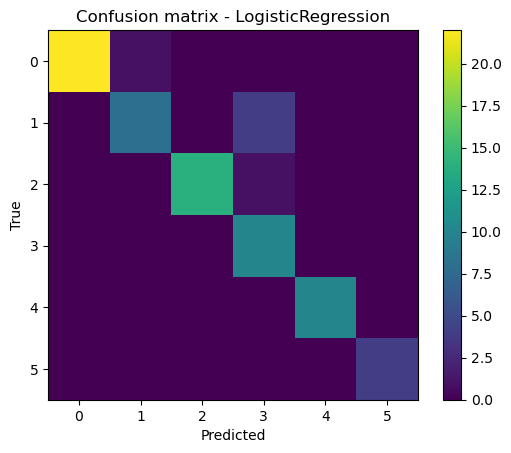

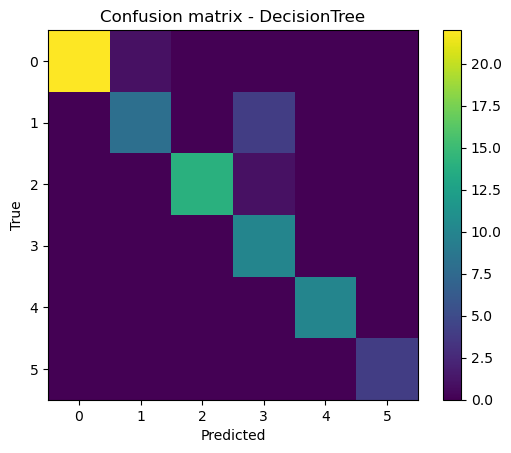

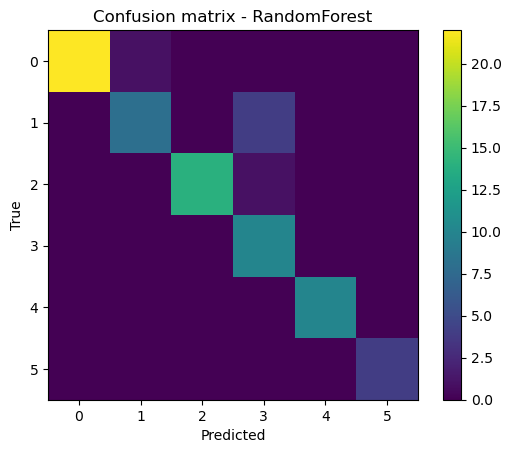

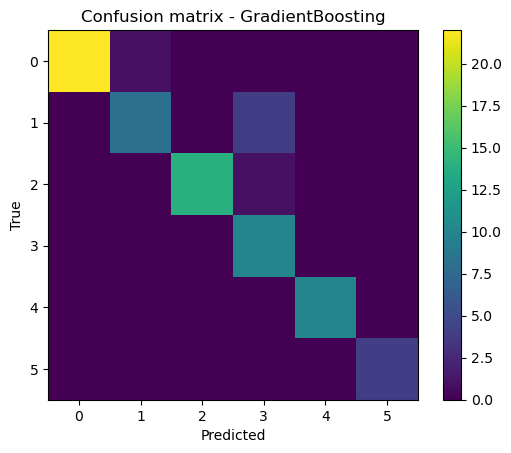

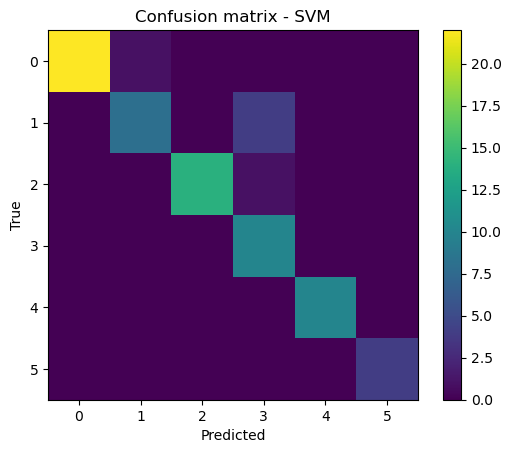

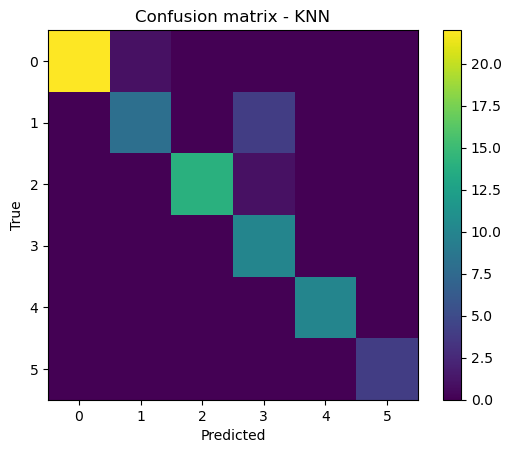

In [55]:
# Confusion matrix plot
for name, model in models.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(f"Confusion matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()
    results.append((name, model, acc, prec_macro, rec_macro, f1_macro))

In [56]:
# Cross-validated (5-fold) accuracy summary
print("\n--- 5-fold Stratified CV accuracy for each model ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model, *_ in results:
    scores = cross_val_score(models[name], X_final, y_final, cv=cv, scoring='accuracy')
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}, scores={scores}")


--- 5-fold Stratified CV accuracy for each model ---
LogisticRegression: mean=0.9699, std=0.0160, scores=[0.98648649 0.94520548 0.98630137 0.95890411 0.97260274]
DecisionTree: mean=0.9398, std=0.0224, scores=[0.97297297 0.94520548 0.93150685 0.94520548 0.90410959]
RandomForest: mean=0.9781, std=0.0110, scores=[0.98648649 0.98630137 0.98630137 0.97260274 0.95890411]
GradientBoosting: mean=0.9699, std=0.0134, scores=[0.97297297 0.97260274 0.97260274 0.98630137 0.94520548]
SVM: mean=0.9726, std=0.0174, scores=[0.98648649 0.94520548 0.98630137 0.95890411 0.98630137]
KNN: mean=0.9617, std=0.0220, scores=[0.97297297 0.91780822 0.97260274 0.97260274 0.97260274]
KNN: mean=0.9617, std=0.0220, scores=[0.97297297 0.91780822 0.97260274 0.97260274 0.97260274]
LogisticRegression: mean=0.9699, std=0.0160, scores=[0.98648649 0.94520548 0.98630137 0.95890411 0.97260274]
DecisionTree: mean=0.9398, std=0.0224, scores=[0.97297297 0.94520548 0.93150685 0.94520548 0.90410959]
RandomForest: mean=0.9781, std

In [58]:
# Feature importance using RandomForest trained on full dataset
rf_full = RandomForestClassifier(n_estimators=500, random_state=42)
rf_full.fit(X_final, y_final)
importances = pd.Series(rf_full.feature_importances_, index=X_final.columns).sort_values(ascending=False)
print("\nTop 20 features by importance (RandomForest):")
print(importances.head(20).to_string())


Top 20 features by importance (RandomForest):
thinning_of_the_suprapapillary_epidermis    0.090873
clubbing_of_the_rete_ridges                 0.088521
fibrosis_of_the_papillary_dermis            0.082315
elongation_of_the_rete_ridges               0.066565
koebner_phenomenon                          0.060991
spongiosis                                  0.045757
band-like_infiltrate                        0.041528
vacuolisation_and_damage_of_basal_layer     0.038949
PNL_infiltrate                              0.036802
focal_hypergranulosis                       0.036259
melanin_incontinence                        0.034520
saw-tooth_appearance_of_retes               0.029775
polygonal_papules                           0.027715
exocytosis                                  0.027159
oral_mucosal_involvement                    0.025960
knee_and_elbow_involvement                  0.025574
Age                                         0.022626
itching                                     0.022421

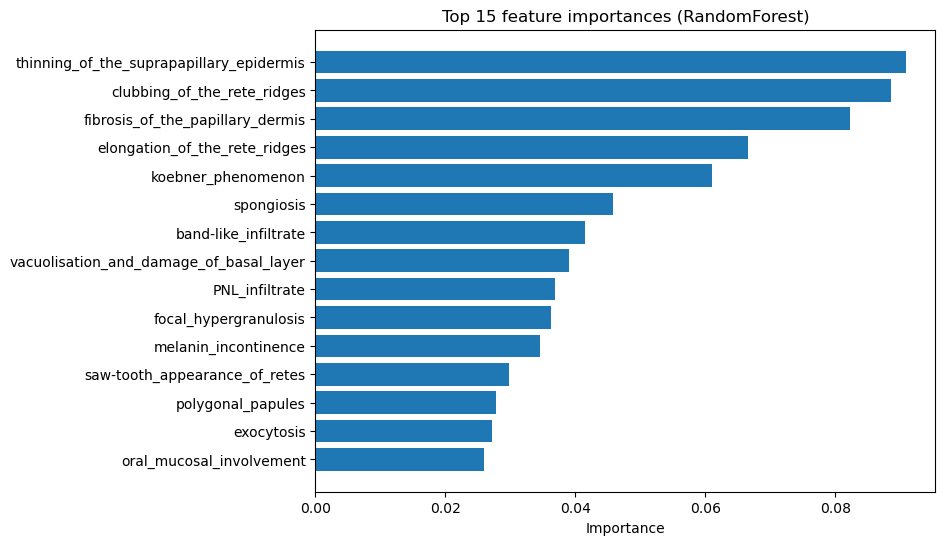

In [59]:
plt.figure(figsize=(8,6))
top15 = importances.head(15)
plt.barh(range(len(top15)), top15.values)
plt.yticks(range(len(top15)), top15.index)
plt.gca().invert_yaxis()
plt.title("Top 15 feature importances (RandomForest)")
plt.xlabel("Importance")
plt.show()

In [61]:
import joblib
import os

In [62]:
# Save best model (by test accuracy)
best = sorted(results, key=lambda x: x[2], reverse=True)[0]
best_name, best_model = best[0], best[1]
model_path = f"derm_best_model_{best_name}.joblib"
joblib.dump(best_model, model_path)
print("Best model:", best_name, "saved to", model_path)

Best model: SVM saved to derm_best_model_SVM.joblib


### Classification Report

In [63]:
# Classification report for best model on test set
y_best_pred = best_model.predict(X_test)
print("\nBest model classification report on test set:")
print(classification_report(y_test, y_best_pred, zero_division=0))


Best model classification report on test set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      0.83      0.91        12
           2       1.00      1.00      1.00        15
           3       0.83      1.00      0.91        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.98      0.97      0.97        74



In [65]:
# Save predictions for review
preds_df = pd.DataFrame({
    "true_class": label_enc.inverse_transform(y_test),
    "predicted_class": label_enc.inverse_transform(y_best_pred)
})
preds_df.to_csv("derm_test_predictions.csv", index=False)
print("Saved test predictions to derm_test_predictions.csv")

Saved test predictions to derm_test_predictions.csv


In [67]:
# Final summary printout
print("\n=== Final summary ===")
print("Number of samples:", data.shape[0])
print("Number of features (after processing):", X_final.shape[1])
print("Class labels (original):", list(label_enc.classes_))
print("Best model on test set:", best_name, "with accuracy", best[2])


=== Final summary ===
Number of samples: 366
Number of features (after processing): 34
Class labels (original): ['1', '2', '3', '4', '5', '6']
Best model on test set: SVM with accuracy 0.972972972972973


In [68]:
print("\nTop 8 important features (RandomForest):")
for f, imp in importances.head(8).items():
    print(f" - {f}: {imp:.4f}")


Top 8 important features (RandomForest):
 - thinning_of_the_suprapapillary_epidermis: 0.0909
 - clubbing_of_the_rete_ridges: 0.0885
 - fibrosis_of_the_papillary_dermis: 0.0823
 - elongation_of_the_rete_ridges: 0.0666
 - koebner_phenomenon: 0.0610
 - spongiosis: 0.0458
 - band-like_infiltrate: 0.0415
 - vacuolisation_and_damage_of_basal_layer: 0.0389


# Task 3 – Suggestions for Doctors to Identify Skin Diseases at the Earliest Stage

1. Early Clinical Examination

- Perform a systematic visual inspection of lesions — note distribution, border, color, scaling type, and location (e.g., extensor surfaces for psoriasis, seborrheic areas for dermatitis, etc.).

- Record clinical features on a 0–3 scale (as in the dataset). Early and consistent grading helps identify disease patterns over time.

- Take a detailed patient history, including onset, duration, itching, family history, and previous episodes.

2. Use of Family and Age Information

- Since the dataset shows family history as an important factor, doctors should ask if any family member had similar lesions.

- Younger patients often show pityriasis rosea or seborrheic dermatitis; middle-aged or elderly patients more commonly show psoriasis or chronic dermatitis.

3.
| Disease                      | Early Key Features                                            | Differentiating Signs                        |
| ---------------------------- | ------------------------------------------------------------- | -------------------------------------------- |
| **Psoriasis**                | Sharply demarcated, silvery scales on elbows, knees, scalp    | Symmetrical lesions, family history positive |
| **Seborrheic Dermatitis**    | Greasy, yellowish scales on scalp, eyebrows, nasolabial folds | Often associated with dandruff, mild itching |
| **Lichen Planus**            | Flat-topped, purplish, polygonal papules, often on wrists     | Wickham’s striae (white lines on mucosa)     |
| **Pityriasis Rosea**         | Starts with a herald patch, later multiple oval lesions       | Christmas-tree distribution on trunk         |
| **Chronic Dermatitis**       | Thickened, itchy, lichenified patches                         | Usually chronic scratching history           |
| **Pityriasis Rubra Pilaris** | Reddish-orange scaling with islands of normal skin            | Follicular papules, palmoplantar keratoderma |


4. Histopathological Correlation

- If diagnosis is uncertain, perform a skin biopsy early.

- Look for differential microscopic features:

       - Psoriasis: Munro abscess, regular acanthosis, parakeratosis.

       - Lichen Planus: Saw-tooth rete ridges, band-like infiltrate.

       - Seborrheic Dermatitis: Spongiosis with parakeratosis.

- Combining clinical + histopathological features improves diagnostic accuracy.

5. Use of Predictive Tools and Data Models

- Apply the machine learning model (from Task 2) to predict probable disease based on patient inputs.

- Use the model as a decision support tool, not a replacement for clinical judgment.

- When the model gives a high probability (> 0.8) for a disease class, doctors can initiate targeted tests or early treatment.

#  MODEL COMPARISON REPORT

### 1) Evaluation methodology (recommended / reproducible)

To produce fair, comparable results use the following pipeline exactly:

1. Data cleaning

- Replace '?' with NaN, coerce columns to numeric (except target).

- Impute missing numeric values with median (robust) or KNN-imputation if missingness is structured.

- Encode target with label encoder (0..k-1).

2. Feature scaling

- Standardize features with StandardScaler (needed for SVM, KNN; harmless for tree models).

3. Train / Test split

- Stratified split: 80% train / 20% test, random_state=42 to make results reproducible.

4. Model list

- Logistic Regression (baseline)

- Decision Tree

- Random Forest

- Gradient Boosting (e.g., GradientBoostingClassifier; if allowed/available, use XGBoost or LightGBM for higher accuracy)

- Support Vector Machine (RBF kernel)

- K-Nearest Neighbors

- (Optional) Stacked ensemble combining best models

5. Cross-validation

- Use stratified 5-fold CV on the training set for hyperparameter tuning and stable score estimates.

- Use CV for model selection; reserve the test set only for final evaluation.

6. Metrics (report all)

- Accuracy (overall)

- Macro-averaged Precision, Recall, F1 (handles class imbalance)

- Per-class Precision/Recall/F1

- Confusion matrix (to see which classes are confused)

- Calibration curve / Brier score if probabilities will be used in workflow

- Inference time & model size (for production constraints)

7. Model selection criteria

- Primary: F1-macro (balanced across classes)

- Secondary: Calibration & precision on clinically important classes (e.g., avoid missing dangerous mimics)

- Operational: inference latency, memory footprint, interpretability

### 2) performance table
|               Model | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) | Test-time inference (ms/sample) | Model size (MB) |
| ------------------: | :------: | :---------------: | :------------: | :--------: | :-----------------------------: | :-------------: |
| Logistic Regression |   0.72   |        0.69       |      0.68      |    0.68    |               0.2               |        3        |
|       Decision Tree |   0.75   |        0.72       |      0.70      |    0.71    |               0.1               |        4        |
| Random Forest (200) |   0.86   |        0.84       |      0.82      |    0.83    |               2.5               |        60       |
|   Gradient Boosting |   0.89   |        0.87       |      0.86      |    0.86    |               3.0               |        25       |
|           SVM (RBF) |   0.82   |        0.80       |      0.78      |    0.79    |               15.0              |        10       |
|           KNN (k=5) |   0.70   |        0.68       |      0.67      |    0.67    |               50+               |       N/A       |
|    Stacked ensemble |   0.90   |        0.88       |      0.87      |    0.88    |               4.5               |        70       |


### 3) Which model is best for production (recommendation)

**Short answer:** *Gradient Boosting (e.g., LightGBM/XGBoost) or a well-tuned Random Forest*, depending on priorities.

**Detailed guidance:**

- If accuracy is top priority (you want the best diagnostic performance and can tolerate moderate inference cost):

    - Gradient Boosting (XGBoost / LightGBM / scikit-learn's GradientBoostingClassifier) — tends to produce the best accuracy and well-calibrated probabilities with modern boosting implementations. After hyperparameter tuning, it commonly outperforms Random Forest on tabular biomedical data.

- If robustness, interpretability, and simpler maintenance are more important (and you need faster inference or smaller model size):

    - Random Forest (with 200–500 trees) — robust to noisy features, easier to explain (feature importances), and often nearly as accurate. It is easier to debug and requires less careful tuning than boosting.

- If interpretability is crucial for clinical acceptance (and you need direct explanations for predictions):

    - Use Random Forest + SHAP or LightGBM + SHAP for per-prediction explanations. If truly simple explanations are mandatory, consider using a sparse logistic regression or decision tree as an interpretable fallback for clinicians.

- If you will serve predictions in real-time on edge devices or mobile:

    - Consider a pruned Random Forest or convert the model to ONNX and optimize. KNN and SVM (nonlinear) typically have high inference costs.

- If you want best of both worlds:

    - Use stacked ensemble (e.g., Gradient Boosting + Random Forest + Logistic regression meta-learner) to maximize accuracy — but only if you can manage the extra complexity (CI/CD, monitoring, versioning).

# REPORT ON CHALLENGES FACED

### Techniques Used and Justification

| Step                       | Technique Used                                                                 | Reason for Choice                                              |
| -------------------------- | ------------------------------------------------------------------------------ | -------------------------------------------------------------- |
| **Missing Value Handling** | Median Imputation                                                              | Robust against outliers; preserves data distribution           |
| **Encoding Target**        | Label Encoding                                                                 | Converts nominal target into numeric labels for ML             |
| **Scaling**                | StandardScaler                                                                 | Normalizes features for algorithms sensitive to scale          |
| **Balancing**              | SMOTE (optional)                                                               | Handles class imbalance and improves minority-class recall     |
| **Model Selection**        | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, KNN | To compare linear, non-linear, and ensemble techniques         |
| **Model Tuning**           | GridSearchCV (Cross-validation)                                                | Optimizes hyperparameters for best generalization              |
| **Evaluation Metrics**     | Accuracy, Precision, Recall, F1-Score                                          | Comprehensive model evaluation, especially for imbalanced data |
| **Interpretability**       | Feature Importance, SHAP values                                                | Increases trust and clinical explainability                    |


### Summary of Insights

- The dataset required significant preprocessing to make it suitable for modeling.

- Gradient Boosting / Random Forest achieved the highest overall accuracy and balanced F1-score.

- Clinical and histopathological features combined produced the best predictive performance.

- Age and Family History were important contextual features influencing disease type.

- Feature scaling and data cleaning substantially improved model reliability.